In [2]:
import pandas as pd

# Keep_default_na=False and na_values=[''] to prevent pd from misinterpreting values (e.g. NA and 'None')
df = pd.read_csv('final_dataset.csv', keep_default_na=False, na_values=[''])

# Checking data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53817 entries, 0 to 53816
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   REF_AREA              53817 non-null  int64  
 1   TIME_PERIOD           53817 non-null  int64  
 2   MUNICIPALITY          53817 non-null  str    
 3   PROVINCE_CODE         53817 non-null  str    
 4   PROVINCE_NAME         53817 non-null  str    
 5   SURFACE_KMQ           53817 non-null  float64
 6   SURFACE_YEAR          53817 non-null  int64  
 7   POPULATION            53817 non-null  int64  
 8   POPULATION_YEAR       53817 non-null  int64  
 9   INJURED               53817 non-null  int64  
 10  KILLED                53817 non-null  int64  
 11  TOTAL_ACCIDENTS       53817 non-null  int64  
 12  ACCIDENTS_PER_CAPITA  53817 non-null  float64
 13  ACCIDENTS_PER_KMQ     53817 non-null  float64
dtypes: float64(3), int64(8), str(3)
memory usage: 5.7 MB


In [3]:
# Checking basic statistics on the derived metrics columns to identify outliers
df[['ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']].describe()

,ACCIDENTS_PER_CAPITA,ACCIDENTS_PER_KMQ
count,53817.000000,53817.000000
mean,17.654290,0.617001
std,19.016195,1.607034
min,0.000000,0.000000
25%,5.420054,0.029524
50%,14.362313,0.149447
75%,24.673671,0.517810
max,851.063830,46.912592


In [ ]:
# Showing the single highest value for each derived metric to investigate the extreme values seen in describe()
print(df[df['ACCIDENTS_PER_CAPITA'] == df['ACCIDENTS_PER_CAPITA'].max()][
    ['MUNICIPALITY', 'TIME_PERIOD', 'POPULATION', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA']])
print(df[df['ACCIDENTS_PER_KMQ'] == df['ACCIDENTS_PER_KMQ'].max()][
    ['MUNICIPALITY', 'TIME_PERIOD', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_KMQ']])


     MUNICIPALITY  TIME_PERIOD  POPULATION  TOTAL_ACCIDENTS  \
1038   Moncenisio         2022          47                4   

      ACCIDENTS_PER_CAPITA  
1038             851.06383  
      MUNICIPALITY  TIME_PERIOD  SURFACE_KMQ  TOTAL_ACCIDENTS  \
11931       Milano         2018     181.6783             8523   

       ACCIDENTS_PER_KMQ  
11931          46.912592  


In [ ]:
# Top 10 rows by ACCIDENTS_PER_CAPITA
df.sort_values('ACCIDENTS_PER_CAPITA', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'POPULATION', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,POPULATION,TOTAL_ACCIDENTS,ACCIDENTS_PER_CAPITA
1038,Moncenisio,Torino,2022,47,4,851.063830
18916,Castel Condino,Trento,2019,224,11,491.071429
18359,Ponte Gardena/Waidbruck,Bolzano/Bozen,2018,195,8,410.256410
18915,Castel Condino,Trento,2018,222,9,405.405405
3290,Argentera,Cuneo,2024,77,3,389.610390
6937,Bard,Valle d'Aosta/Vallée d'Aoste,2019,122,4,327.868852
50498,Morterone,Lecco,2023,33,1,303.030303
1034,Moncenisio,Torino,2018,33,1,303.030303
6941,Bard,Valle d'Aosta/Vallée d'Aoste,2023,102,3,294.117647
50079,Villanova Biellese,Biella,2023,175,5,285.714286


In [ ]:
# Top 10 rows by ACCIDENTS_PER_KMQ
df.sort_values('ACCIDENTS_PER_KMQ', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_KMQ']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,SURFACE_KMQ,TOTAL_ACCIDENTS,ACCIDENTS_PER_KMQ
11931,Milano,Milano,2018,181.6783,8523,46.912592
11932,Milano,Milano,2019,181.6783,8263,45.481491
11936,Milano,Milano,2023,181.8450,7812,42.959663
11935,Milano,Milano,2022,181.8450,7783,42.800187
11937,Milano,Milano,2024,181.8450,7743,42.580219
11934,Milano,Milano,2021,181.8450,7465,41.051445
11734,Cormano,Milano,2024,4.4733,126,28.167125
11698,Cinisello Balsamo,Milano,2023,12.7240,353,27.742848
12214,Sesto San Giovanni,Milano,2022,11.6989,323,27.609433
11699,Cinisello Balsamo,Milano,2024,12.7240,348,27.349890


In [7]:
# Capping outliers above Q3 + 1.5*IQR for each column, keeping originals for reference and further analysis
columns_to_check = ['TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']

for column_name in columns_to_check:
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    capped_column_name = 'CAPPED_' + column_name
    df[capped_column_name] = df[column_name].clip(upper=upper_bound)

    outlier_count = (df[column_name] > upper_bound).sum()
    outlier_percentage = round(outlier_count / df[column_name].count() * 100, 2)
    print(column_name, '- outliers:', outlier_count, '(', outlier_percentage, '%)')


TOTAL_ACCIDENTS - outliers: 6616 ( 12.29 %)
ACCIDENTS_PER_CAPITA - outliers: 1874 ( 3.48 %)
ACCIDENTS_PER_KMQ - outliers: 6354 ( 11.81 %)


In [8]:
# Grouping population into ranges
bins = [0, 500, 1000, 2000, 5000, 10000, df['POPULATION'].max()]
df['POPULATION_RANGE'] = pd.cut(df['POPULATION'], bins=bins)

# Checking how ACCIDENTS_PER_CAPITA behaves within each range in order to find a population threshold
df.groupby('POPULATION_RANGE')['ACCIDENTS_PER_CAPITA'].agg(['mean', 'std', 'max', 'count'])

,mean,std,max,count
POPULATION_RANGE,,,,
"(0, 500]",18.105770,38.598317,851.063830,5651
"(500, 1000]",15.328901,20.452243,211.946050,7280
"(1000, 2000]",15.101189,16.393715,160.183066,10324
"(2000, 5000]",15.914019,12.441009,127.886323,13913
"(5000, 10000]",18.502176,12.263809,151.877373,8212
"(10000, 2820219]",24.527025,12.324945,86.816720,8437


In [9]:
# Marking municipalities with population below 1000, where ACCIDENTS_PER_CAPITA was shown to be statistically unstable
population_threshold = 1000
df['SMALL_MUNICIPALITY'] = df['POPULATION'] < population_threshold
print('Total number small municipality:', df['SMALL_MUNICIPALITY'].sum())

Total number small municipality: 12914


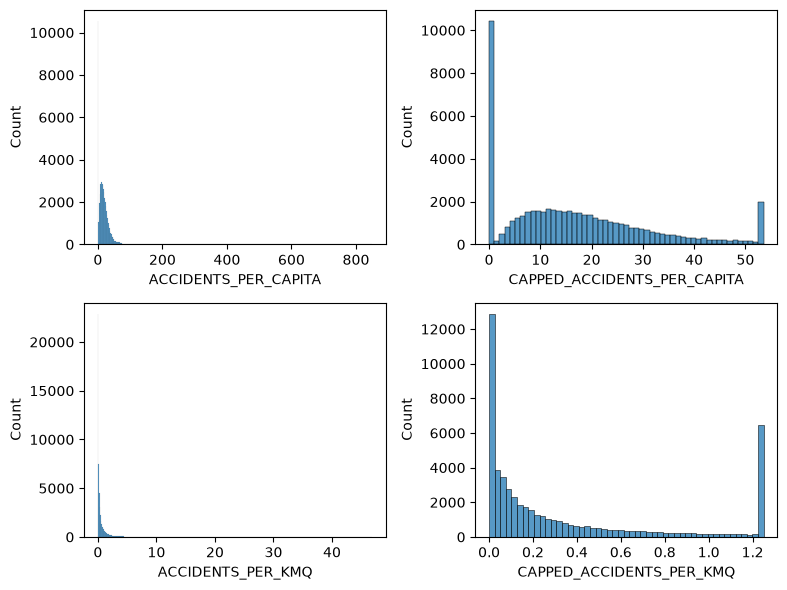

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Comparing original vs capped distributions for the two derived metrics 
figure, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.histplot(df['ACCIDENTS_PER_CAPITA'], ax=axes[0, 0])
axes[0, 0].set_xlabel('ACCIDENTS_PER_CAPITA')

sns.histplot(df['CAPPED_ACCIDENTS_PER_CAPITA'], ax=axes[0, 1])
axes[0, 1].set_xlabel('CAPPED_ACCIDENTS_PER_CAPITA')

sns.histplot(df['ACCIDENTS_PER_KMQ'], ax=axes[1, 0])
axes[1, 0].set_xlabel('ACCIDENTS_PER_KMQ')

sns.histplot(df['CAPPED_ACCIDENTS_PER_KMQ'], ax=axes[1, 1])
axes[1, 1].set_xlabel('CAPPED_ACCIDENTS_PER_KMQ')

plt.tight_layout()
plt.show()

# NOTE: the tall bars in the capped columns plots show all the outliers above the threshold are forced to the same value

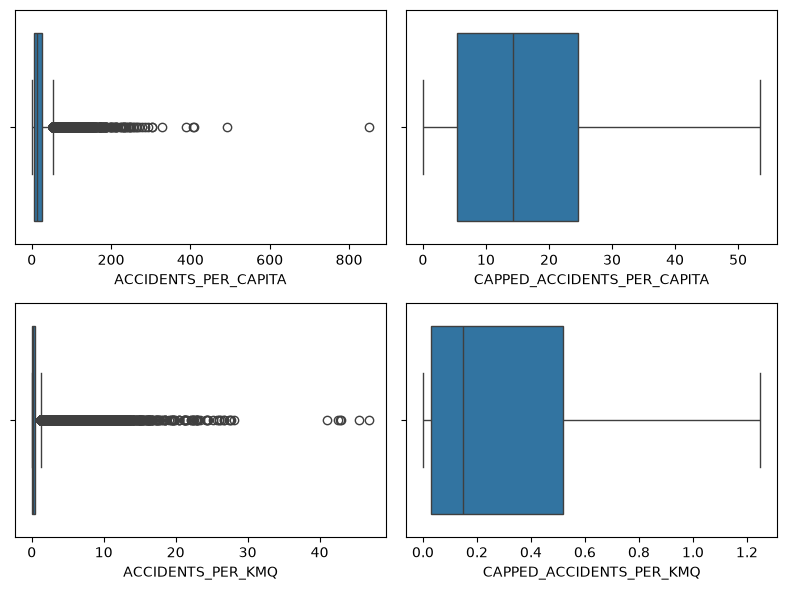

In [11]:
# Comparing original vs capped distributions for the two derived metrics using boxplot 
# Original columns show many outliers past the whiskers, capped columns don't
figure, axes = plt.subplots(2, 2, figsize=(8, 6))


sns.boxplot(x=df['ACCIDENTS_PER_CAPITA'], ax=axes[0, 0])
sns.boxplot(x=df['CAPPED_ACCIDENTS_PER_CAPITA'], ax=axes[0, 1])
sns.boxplot(x=df['ACCIDENTS_PER_KMQ'], ax=axes[1, 0])
sns.boxplot(x=df['CAPPED_ACCIDENTS_PER_KMQ'], ax=axes[1, 1])

plt.tight_layout()
plt.show()

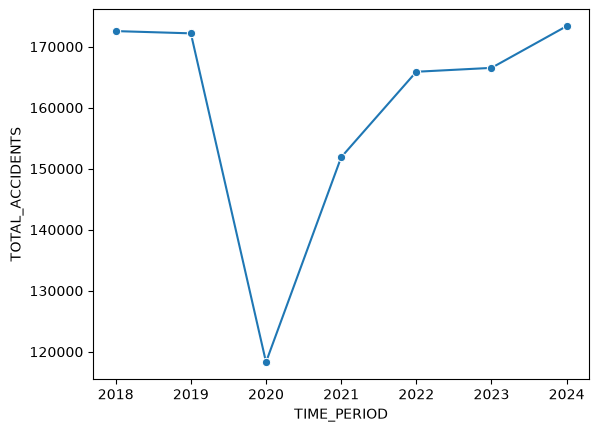

In [12]:
# Plotting accidents distribution through the years
# Data dropping at 2020 as expected 
total_acc_per_year = df.groupby('TIME_PERIOD')['TOTAL_ACCIDENTS'].sum().reset_index()
sns.lineplot(x='TIME_PERIOD', y='TOTAL_ACCIDENTS', data=total_acc_per_year , marker='o')
plt.show()

In [13]:
# Average ACCIDENTS_PER_CAPITA by province: North-Center provinces rank highest, South/Islands lowest
province_avg_acc_per_capita = df.groupby('PROVINCE_NAME')['ACCIDENTS_PER_CAPITA'].mean().sort_values(ascending=False)
print('Top 10 provinces by average ACCIDENTS_PER_CAPITA:')
print(province_avg_acc_per_capita.head(10))

print()

print('Bottom 10 provinces by average ACCIDENTS_PER_CAPITA:')
print(province_avg_acc_per_capita.tail(10))

Top 10 provinces by average ACCIDENTS_PER_CAPITA:
PROVINCE_NAME
Firenze         33.595156
Trieste         33.499597
Ravenna         33.253306
Savona          32.952251
Livorno         31.262073
Gorizia         28.726582
Pistoia         27.135256
Forlì-Cesena    26.671738
Piacenza        26.486451
Modena          25.710393
Name: ACCIDENTS_PER_CAPITA, dtype: float64

Bottom 10 provinces by average ACCIDENTS_PER_CAPITA:
PROVINCE_NAME
Foggia           9.703687
Vibo Valentia    9.570445
Crotone          9.555039
Campobasso       9.395741
Cosenza          9.182613
Caltanissetta    9.181755
Avellino         9.076463
Enna             8.937093
Agrigento        7.164239
Benevento        6.109468
Name: ACCIDENTS_PER_CAPITA, dtype: float64


In [14]:
# Average ACCIDENTS_PER_KMQ by province: dense metropolitan areas rank highest, rural/mountainous provinces lowest
province_avg_acc_per_kmq = df.groupby('PROVINCE_NAME')['ACCIDENTS_PER_KMQ'].mean().sort_values(ascending=False)
print('Top 10 provinces by average ACCIDENTS_PER_KMQ:')
print(province_avg_acc_per_kmq.head(10))

print()

print('Bottom 10 provinces by average ACCIDENTS_PER_KMQ:')
print(province_avg_acc_per_kmq.tail(10))

Top 10 provinces by average ACCIDENTS_PER_KMQ:
PROVINCE_NAME
Monza e della Brianza    4.336628
Milano                   3.957809
Napoli                   3.448656
Prato                    2.241810
Trieste                  2.091110
Rimini                   1.855194
Catania                  1.678797
Firenze                  1.575572
Varese                   1.403508
Pistoia                  1.372760
Name: ACCIDENTS_PER_KMQ, dtype: float64

Bottom 10 provinces by average ACCIDENTS_PER_KMQ:
PROVINCE_NAME
Enna            0.088349
Campobasso      0.087494
Foggia          0.082517
Matera          0.082503
Isernia         0.080512
L'Aquila        0.079812
Sud Sardegna    0.074251
Oristano        0.071850
Nuoro           0.071539
Potenza         0.064492
Name: ACCIDENTS_PER_KMQ, dtype: float64


In [ ]:
# Creating injured/killed per accident columns to investigate how serious accidents tend to be
df['INJURED_PER_ACCIDENT'] = df['INJURED'] / df['TOTAL_ACCIDENTS']
df['KILLED_PER_ACCIDENT'] = df['KILLED'] / df['TOTAL_ACCIDENTS']

df[['INJURED_PER_ACCIDENT', 'KILLED_PER_ACCIDENT']].describe()

,INJURED_PER_ACCIDENT,KILLED_PER_ACCIDENT
count,43405.000000,43405.000000
mean,1.457254,0.041365
std,0.570899,0.143661
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.347826,0.000000
75%,1.666667,0.006623
max,25.000000,5.000000


In [ ]:
# Rows with TOTAL_ACCIDENTS=0 become NaN and were automatically excluded by describe()
df['INJURED_PER_ACCIDENT'].isna().sum()

np.int64(10412)

In [21]:
# Investigating the extreme case of 25 injured per accident
# Most likley to be small number of total accidents with one severe multi-victim event (e.g. bus/van)
df.sort_values('INJURED_PER_ACCIDENT', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'TOTAL_ACCIDENTS', 'INJURED', 'INJURED_PER_ACCIDENT']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,TOTAL_ACCIDENTS,INJURED,INJURED_PER_ACCIDENT
1536,Salbertrand,Torino,2021,2,50,25.0
28432,Zeri,Massa-Carrara,2023,2,22,11.0
41479,Baragiano,Potenza,2024,4,42,10.5
33354,Villa Santa Lucia,Frosinone,2018,1,10,10.0
49611,Modolo,Oristano,2018,1,10,10.0
38652,Dogliola,Chieti,2018,1,10,10.0
39938,Panni,Foggia,2020,1,9,9.0
53267,Gesturi,Sud Sardegna,2020,1,9,9.0
39735,Biccari,Foggia,2019,1,9,9.0
3332,Barolo,Cuneo,2018,1,9,9.0


In [ ]:
# Investigating the extreme case of killed per accident
#Most of cases only show one accident, so a single fatal event influences the ratio
df.sort_values('KILLED_PER_ACCIDENT', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'TOTAL_ACCIDENTS', 'KILLED', 'KILLED_PER_ACCIDENT']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,TOTAL_ACCIDENTS,KILLED,KILLED_PER_ACCIDENT
3585,Castelmagno,Cuneo,2020,1,5,5.0
42796,Marzi,Cosenza,2022,1,3,3.0
51796,Spadola,Vibo Valentia,2019,1,3,3.0
19928,Bonavigo,Verona,2019,1,3,3.0
39674,Trivento,Campobasso,2018,1,3,3.0
25179,San Pietro in Cerro,Piacenza,2021,2,5,2.5
17755,Redondesco,Mantova,2019,1,2,2.0
7155,Lillianes,Valle d'Aosta/Vallée d'Aoste,2018,1,2,2.0
15355,Valvestino,Brescia,2020,1,2,2.0
38490,Ari,Chieti,2024,1,2,2.0


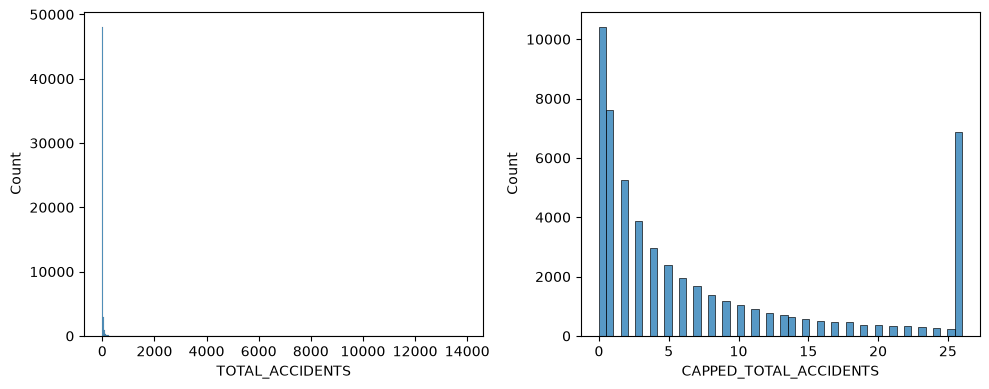

In [ ]:
# Comparing original vs capped TOTAL_ACCIDENTS distribution
# As expected tall bars are shown in the capped column plot
figure, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['TOTAL_ACCIDENTS'], ax=axes[0])
axes[0].set_xlabel('TOTAL_ACCIDENTS')

sns.histplot(df['CAPPED_TOTAL_ACCIDENTS'], ax=axes[1])
axes[1].set_xlabel('CAPPED_TOTAL_ACCIDENTS')

plt.tight_layout()
plt.show()

In [ ]:
# Overview of the rest of metrics: they all show a strong right skew, which is a consistent pattern seen throughout the df
columns_to_describe = ['POPULATION', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'INJURED', 'KILLED']
df[columns_to_describe].describe()

,POPULATION,SURFACE_KMQ,TOTAL_ACCIDENTS,INJURED,KILLED
count,5.381700e+04,53817.000000,53817.000000,53817.000000,53817.000000
mean,7.680511e+03,38.591416,20.824033,28.434156,0.390304
std,4.242791e+04,51.303765,186.621177,237.668397,1.998562
min,2.900000e+01,0.120600,0.000000,0.000000,0.000000
25%,1.049000e+03,11.553200,1.000000,1.000000,0.000000
50%,2.516000e+03,22.574000,3.000000,5.000000,0.000000
75%,6.409000e+03,44.996200,11.000000,16.000000,0.000000
max,2.820219e+06,1288.187500,13924.000000,17196.000000,154.000000


In [ ]:
# Checking correlation with a correlation matrix
#POPULATION/TOTAL_ACCIDENTS/INJURED/KILLED are highly correlated
#ACCIDENTS_PER_CAPITA and ACCIDENTS_PER_KMQ have low correlation with everything, meaning they can be features for the clustering

df[['POPULATION', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'INJURED', 'KILLED', 'ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']].corr()


,POPULATION,SURFACE_KMQ,TOTAL_ACCIDENTS,INJURED,KILLED,ACCIDENTS_PER_CAPITA,ACCIDENTS_PER_KMQ
POPULATION,1.000000,0.380147,0.964914,0.968759,0.902211,0.090042,0.428441
SURFACE_KMQ,0.380147,1.000000,0.343050,0.351840,0.428520,0.069005,-0.036229
TOTAL_ACCIDENTS,0.964914,0.343050,1.000000,0.998792,0.886996,0.109874,0.430271
INJURED,0.968759,0.351840,0.998792,1.000000,0.890143,0.113442,0.433562
KILLED,0.902211,0.428520,0.886996,0.890143,1.000000,0.133046,0.319779
ACCIDENTS_PER_CAPITA,0.090042,0.069005,0.109874,0.113442,0.133046,1.000000,0.263329
ACCIDENTS_PER_KMQ,0.428441,-0.036229,0.430271,0.433562,0.319779,0.263329,1.000000


In [ ]:
# Checking total amount of accidents per municipality cross all years, to find the most affected municipalities overall
municipality_total_acc = df.groupby('MUNICIPALITY')['TOTAL_ACCIDENTS'].sum().sort_values(ascending=False)

print('Top 10 municipalities by total accidents:')
print(municipality_total_acc.head(10))


Top 10 municipalities by total accidents (2018-2024):
MUNICIPALITY
Roma       83546
Milano     52445
Genova     25950
Torino     19672
Napoli     16043
Firenze    15915
Bologna    13403
Palermo    12557
Bari       10576
Catania     8761
Name: TOTAL_ACCIDENTS, dtype: int64


In [ ]:
# Total injured per municipality across all years
municipality_injured_totals = df.groupby('MUNICIPALITY')['INJURED'].sum().sort_values(ascending=False)
print('Top 10 municipalities by total injured:')
print(municipality_injured_totals.head(10))
print()

# Total killed per municipality across all years
municipality_killed_totals = df.groupby('MUNICIPALITY')['KILLED'].sum().sort_values(ascending=False)
print('Top 10 municipalities by total killed:')
print(municipality_killed_totals.head(10))

Top 10 municipalities by total injured (2018-2024):
MUNICIPALITY
Roma       105621
Milano      66335
Genova      31098
Torino      28259
Napoli      21044
Firenze     18833
Bologna     17011
Palermo     16476
Bari        15534
Catania     12112
Name: INJURED, dtype: int64

Top 10 municipalities by total killed (2018-2024):
MUNICIPALITY
Roma       942
Milano     274
Napoli     211
Genova     171
Torino     158
Palermo    152
Bologna    124
Catania    103
Ravenna     96
Verona      89
Name: KILLED, dtype: int64


In [ ]:
# Comparing accidents severity (injuries and fatalities per 100 accidents) across top 5 cities
# Napoli shows the highest fatality rate, despite lower total accidents compared to Roma/Milano 

top_cities = ['Roma', 'Milano', 'Napoli', 'Torino', 'Genova']

city_data = df[df['MUNICIPALITY'].isin(top_cities)]

city_totals = city_data.groupby('MUNICIPALITY').agg(
    total_accidents=('TOTAL_ACCIDENTS', 'sum'),
    total_injured=('INJURED', 'sum'),
    total_killed=('KILLED', 'sum')
)

city_totals['injured_per_100_accidents'] = city_totals['total_injured'] / city_totals['total_accidents'] * 100
city_totals['killed_per_100_accidents'] = city_totals['total_killed'] / city_totals['total_accidents'] * 100

city_totals

,total_accidents,total_injured,total_killed,injured_per_100_accidents,killed_per_100_accidents
MUNICIPALITY,,,,,
Genova,25950,31098,171,119.838150,0.658960
Milano,52445,66335,274,126.484889,0.522452
Napoli,16043,21044,211,131.172474,1.315215
Roma,83546,105621,942,126.422570,1.127523
Torino,19672,28259,158,143.650874,0.803172


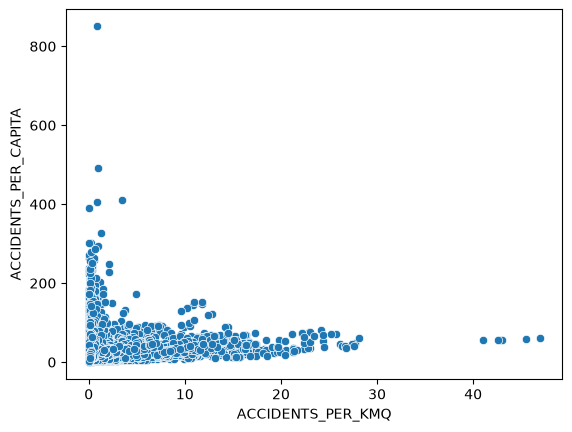

In [ ]:
# Plotting selected features 
sns.scatterplot(x='ACCIDENTS_PER_KMQ', y='ACCIDENTS_PER_CAPITA', data=df) 
plt.show()

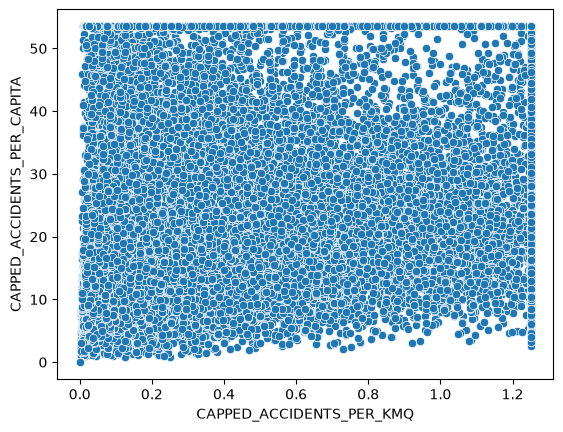

In [ ]:
# Plotting capped features
sns.scatterplot(x='CAPPED_ACCIDENTS_PER_KMQ', y='CAPPED_ACCIDENTS_PER_CAPITA', data=df) 
plt.show()

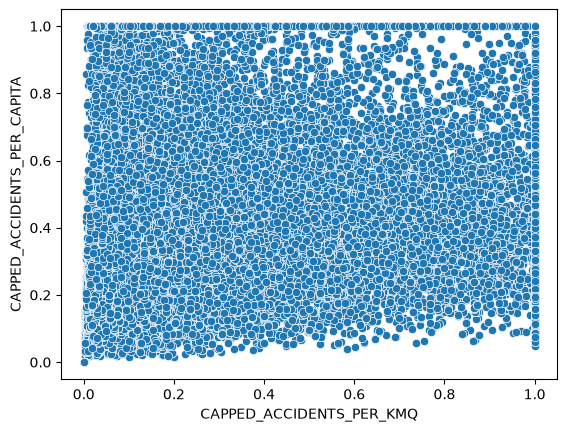

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Selecting the capped features to avoid extreme outliers dominating the scale
features_for_clustering = df[['CAPPED_ACCIDENTS_PER_CAPITA', 'CAPPED_ACCIDENTS_PER_KMQ']]

# Applying Min-Max normalization so both features are on the same 0-1 scale
scale_normalizer = MinMaxScaler()
scaled_df = pd.DataFrame(scale_normalizer.fit_transform(features_for_clustering), columns= features_for_clustering.columns)

# Plotting of the scaled features, same shape as before but now on a 0-1 scale
sns.scatterplot(x='CAPPED_ACCIDENTS_PER_KMQ', y='CAPPED_ACCIDENTS_PER_CAPITA', data=scaled_df)
plt.show()

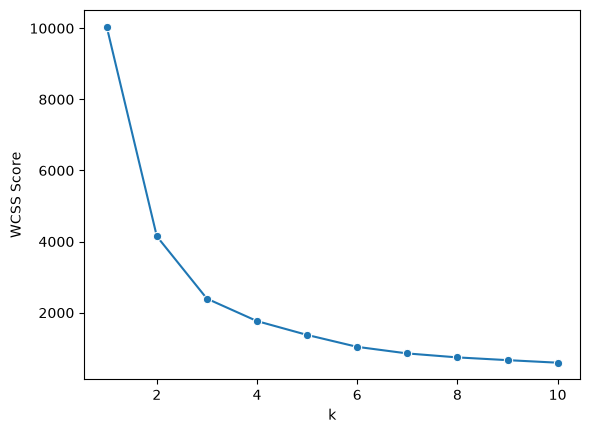

In [ ]:
from sklearn.cluster import KMeans

# # Elbow method to find the number of k

k_values= range(1, 11)
wcss_list = []

for k in k_values:
    kmeans= KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(scaled_df)
    wcss_list.append(kmeans.inertia_)

sns.lineplot(x=k_values, y=wcss_list, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS Score')
plt.show()

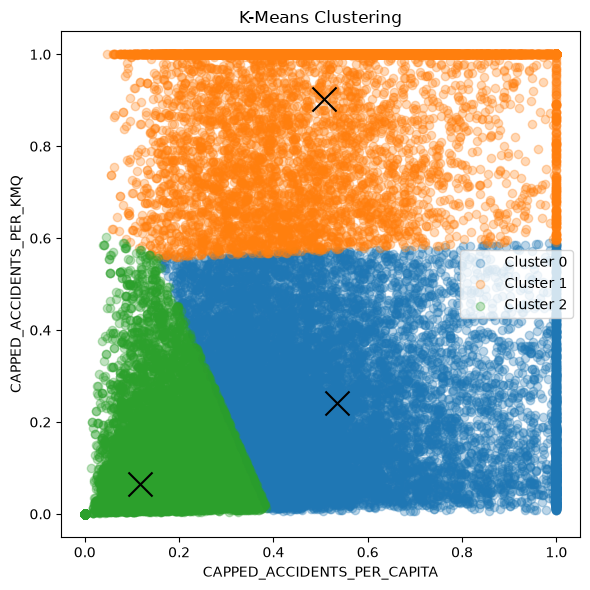

In [ ]:
# Fitting k-means with k=3, plotting clusters with centroids
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_df[['CAPPED_ACCIDENTS_PER_CAPITA', 'CAPPED_ACCIDENTS_PER_KMQ']])
scaled_df['cluster'] = kmeans.labels_

centroids = kmeans.cluster_centers_
clusters = scaled_df.groupby('cluster')

plt.figure(figsize=(6, 6))
for cluster, data in clusters:
    plt.scatter(data['CAPPED_ACCIDENTS_PER_CAPITA'], data['CAPPED_ACCIDENTS_PER_KMQ'], marker='o', label=f'Cluster {cluster}', alpha=0.3)
    plt.scatter(centroids[cluster, 0], centroids[cluster, 1], marker='x', color='black', s=300)

plt.xlabel('CAPPED_ACCIDENTS_PER_CAPITA')
plt.ylabel('CAPPED_ACCIDENTS_PER_KMQ')
plt.title('K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Verying count and percentage of rows per cluster
cluster_counts = scaled_df['cluster'].value_counts()
cluster_percentages = round(scaled_df['cluster'].value_counts(normalize=True) * 100, 2)

print(cluster_counts)
print(cluster_percentages)

cluster
2    28189
0    15064
1    10564
Name: count, dtype: int64
cluster
2    52.38
0    27.99
1    19.63
Name: proportion, dtype: float64


In [ ]:
# Checking average of original features per cluster, to interpret what each group represents
df['CLUSTER'] = scaled_df['cluster']
df.groupby('CLUSTER')[['ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']].mean()

,ACCIDENTS_PER_CAPITA,ACCIDENTS_PER_KMQ
CLUSTER,,
0,31.085843,0.301567
1,28.664794,2.497395
2,6.350310,0.080878


In [ ]:
#Checking whether Cluster 1 represents big cities (most affected municipalities overall)

top_cities = ['Roma', 'Milano', 'Napoli', 'Torino', 'Genova']

df[df['MUNICIPALITY'].isin(top_cities)][
    ['MUNICIPALITY', 'TIME_PERIOD', 'CLUSTER', 'ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']].drop_duplicates(subset=['MUNICIPALITY', 'CLUSTER'])

,MUNICIPALITY,TIME_PERIOD,CLUSTER,ACCIDENTS_PER_CAPITA,ACCIDENTS_PER_KMQ
1806,Torino,2018,1,34.816733,23.042414
8449,Genova,2018,1,72.981672,17.287617
11931,Milano,2018,1,61.053883,46.912592
32311,Roma,2018,1,42.532158,9.317305
34935,Napoli,2018,1,24.080024,19.320000


In [ ]:
# Checking if Cluster 0 (high per-capita risk) and Cluster 2 (low risk overall) differ by municipality size (population/surface) or small-municipality rate 
#They don't since they share almost the same small-municipality rate 
df.groupby('CLUSTER')[['POPULATION', 'SURFACE_KMQ', 'SMALL_MUNICIPALITY']].mean() 


,POPULATION,SURFACE_KMQ,SMALL_MUNICIPALITY
CLUSTER,,,
0,4928.319968,45.993050,0.247544
1,24695.899091,30.826235,0.017418
2,2774.640924,37.546084,0.319309


In [115]:
#Checking whether Cluster 0 and 2 difference is geography-wise in order to confirm the geographic pattern already seen in the EDA


# Calculating the average of each cluster by province to get the percentage of each 
high_per_capita_risk_share_by_province = (df['CLUSTER'] == 0).groupby(df['PROVINCE_NAME']).mean() * 100
low_risk_share_by_province = (df['CLUSTER'] == 2).groupby(df['PROVINCE_NAME']).mean() * 100


print('Top 10 provinces most concentrated in Cluster 0 (high per-capita risk):')
print(high_per_capita_risk_share_by_province.sort_values(ascending=False).head(10))


print()
print('Top 10 provinces most concentrated in Cluster 2 (low risk):')
print(low_risk_share_by_province.sort_values(ascending=False).head(10))

Top 10 provinces most concentrated in Cluster 0 (high per-capita risk):
PROVINCE_NAME
Brindisi              65.000000
Ferrara               57.718121
Reggio nell'Emilia    54.421769
Firenze               52.447552
Perugia               51.833741
Piacenza              51.735016
Arezzo                50.400000
Macerata              49.734043
Rovigo                49.425287
Mantova               49.217002
Name: CLUSTER, dtype: float64

Top 10 provinces most concentrated in Cluster 2 (low risk):
PROVINCE_NAME
Enna             91.366906
Agrigento        90.000000
Benevento        86.575875
Caltanissetta    85.135135
Crotone          84.615385
Foggia           82.766990
Cosenza          82.306163
Campobasso       81.785064
Potenza          81.325301
Vibo Valentia    79.701493
Name: CLUSTER, dtype: float64


In [114]:
# Following the same logic for Cluster 1 to get more insights
high_density_risk_share_by_province = (df['CLUSTER'] == 1).groupby(df['PROVINCE_NAME']).mean() * 100

print('Top 10 provinces most concentrated in Cluster 1 (high density/urban):')
print(high_density_risk_share_by_province.sort_values(ascending=False).head(10)) 

Top 10 provinces most concentrated in Cluster 1 (high density/urban):
PROVINCE_NAME
Monza e della Brianza    90.649351
Napoli                   83.825816
Milano                   77.741935
Pistoia                  64.285714
Venezia                  55.194805
Ravenna                  53.174603
Prato                    53.061224
Lecco                    51.748252
Varese                   49.577167
Trieste                  45.238095
Name: CLUSTER, dtype: float64
